In [ ]:
!pip install xlsxwriter


In [ ]:
# ==============================
# Imports & file upload
# ==============================
import pandas as pd
import numpy as np

from google.colab import files

uploaded = files.upload()

FILE_NAME = list(uploaded.keys())[0]
print("Using file:", FILE_NAME)

df = pd.read_csv(FILE_NAME)
print("Loaded shape:", df.shape)
df.head()


Saving Final_Task_Data.csv to Final_Task_Data.csv
Using file: Final_Task_Data.csv
Loaded shape: (7692, 108)


,ID,Age,Team,League,Season,Minutes,Np_xg_per_shot,Np_xg,Np_shots,Goals,...,Successful_counterpressures,Pressing_distance,Opp_half_pressures,Opp_half_counterpressures,Ball_recoveries,Np_psxg,Penalties_faced,Penalties_conceded,Defensive_actions,Value
0,47196,30,Haugesund,Eliteserien,2025,1391.783,0.054,0.070,1.293,0.000,...,1.681,39.457,8.212,3.621,7.501,0.014,0.000,0.000,29.940,250.0k
1,75938,32,Molde,Eliteserien,2025,194.750,NaN,0.000,0.000,0.000,...,0.000,NaN,0.000,0.000,3.235,0.000,0.000,0.000,0.000,150.0k
2,18605,30,Bodo / Glimt,Eliteserien,2025,2861.416,NaN,0.000,0.000,0.000,...,0.000,3.673,0.000,0.000,3.460,0.000,0.063,0.063,0.063,2.0m
3,67388,27,Rosenborg BK,Eliteserien,2025,1007.800,0.063,0.079,1.250,0.089,...,0.447,46.342,3.929,1.965,6.876,0.068,0.000,0.000,9.823,450.0k
4,91297,27,Sandefjord,Eliteserien,2025,1887.484,NaN,0.000,0.000,0.000,...,0.000,5.625,0.000,0.000,3.815,0.000,0.381,0.334,0.381,350.0k


In [ ]:
# ==============================
# Basic column configuration
# ==============================

ID_COL = "ID"
AGE_COL = "Age"
MINUTES_COL = "Minutes"
POS1_COL = "Position_1"
POS2_COL = "Position_2"

important_cols = [ID_COL, AGE_COL, MINUTES_COL, POS1_COL, POS2_COL]
missing_important = [c for c in important_cols if c not in df.columns]
if missing_important:
    print("WARNING: These important columns were not found:", missing_important)
else:
    print("All important identifier columns found.")


All important identifier columns found.


In [ ]:
# ==============================
# Metric configuration
#    direction = 'high_good' or 'low_good'
# ==============================

METRIC_CONFIG = {
    "Np_xg_per_shot":             {"direction": "high_good"},  # better shot quality
    "Np_xg":                      {"direction": "high_good"},
    "Np_shots":                   {"direction": "high_good"},
    "Goals":                      {"direction": "high_good"},
    "Xa":                         {"direction": "high_good"},
    "Key_passes":                 {"direction": "high_good"},
    "Op_key_passes":              {"direction": "high_good"},
    "Assists":                    {"direction": "high_good"},
    "Through_balls":              {"direction": "high_good"},
    "Passes_into_box":            {"direction": "high_good"},
    "Op_passes_into_box":         {"direction": "high_good"},
    "Touches_in_box":             {"direction": "high_good"},
    "Tackles":                    {"direction": "high_good"},
    "Interceptions":              {"direction": "high_good"},
    "Padj_tackles":               {"direction": "high_good"},
    "Padj_interceptions":         {"direction": "high_good"},
    "Dribbles_successful":        {"direction": "high_good"},
    "Dribbled_past":              {"direction": "low_good"},
    "Fouls":                      {"direction": "low_good"},
    "Dispossessed":               {"direction": "low_good"},
    "Long_ball_percentage":       {"direction": "high_good"},
    "Long_balls":                 {"direction": "low_good"},  # perhaps not what Celtic want in a player
    "Block_per_shot":             {"direction": "high_good"},
    "Clearance":                  {"direction": "high_good"},
    "Aerial_percentage":          {"direction": "high_good"},
    "Aerial_won":                 {"direction": "high_good"},
    "Op_passes":                  {"direction": "high_good"},
    "Forward_pass_proportion":    {"direction": "high_good"},
    "Backward_pass_proportion":   {"direction": "low_good"},
    "Op_last_3rd_passes":         {"direction": "high_good"},
    "Last_3rd_forward_pass_proportion":  {"direction": "high_good"},
    "Last_3rd_backward_pass_proportion": {"direction": "high_good"},
    "Shot_target_percentage":     {"direction": "high_good"},
    "Passing_percentage":         {"direction": "high_good"},
    "Goal_conversion":            {"direction": "high_good"},
    "Np_goals":                   {"direction": "high_good"},
    "Crosses_completed":          {"direction": "high_good"},
    "Crossing_percentage":        {"direction": "high_good"},
    "Penalty_won":                {"direction": "high_good"},
    "Padj_Clearances":            {"direction": "high_good"},
    "Passes_inside_box":          {"direction": "high_good"},
    "Xgchain":                    {"direction": "high_good"},
    "Op_xgchain":                 {"direction": "high_good"},
    "Xgbuildup":                  {"direction": "high_good"},
    "Op_xgbuildup":               {"direction": "high_good"},
    "Op_xa":                      {"direction": "high_good"},
    "Op_assists":                 {"direction": "high_good"},
    "Xgchain_per_possession":     {"direction": "high_good"},
    "Op_xgchain_per_possession":  {"direction": "high_good"},
    "Xgbuildup_per_possession":   {"direction": "high_good"},
    "Op_xgbuildup_per_possession":{"direction": "high_good"},
    "Long_Balls_under_pressure":  {"direction": "high_good"},
    "Long_Balls_without_pressure":{"direction": "low_good"},   # again not necessarily how celtic want to play
    "Pressures":                  {"direction": "high_good"},
    "Turnovers":                  {"direction": "low_good"},
    "Successful_pressures":       {"direction": "high_good"},
    "Sp_xa":                      {"direction": "high_good"},
    "Shot_per_touch":             {"direction": "high_good"},
    "Pass_and_carry_last_3rd":    {"direction": "high_good"},
    "Fouls_won":                  {"direction": "high_good"},

    # GK metrics – some team-effect, but treating more shots faced as worse
    "Shots_faced":                {"direction": "low_good"},
    "Goals_conceded":             {"direction": "low_good"},
    "Np_xg_faced":                {"direction": "low_good"},
    "Shots_on_target_faced":                 {"direction": "low_good"},
    "Np_psxg_faced":              {"direction": "low_good"}, # not sure all of these are down to the goalkeeper
    "Save_percentage":            {"direction": "high_good"},
    "Xsave_percentage":           {"direction": "high_good"},
    "Goals_saved_above_avg":      {"direction": "high_good"},
    "Gk_defesive_action_distance": {"direction": "high_good"},  # dependent on goalkeeper type wanted

    "Passing_percentage_under_pressure":     {"direction": "high_good"},
    "Percentage_passes_under_pressure":      {"direction": "high_good"},
    "Attempted_pass_length":                 {"direction": "high_good"}, # nuanced metrics dependent on player desires
    "Successful_pass_length":                {"direction": "high_good"}, # nuanced metrics dependent on player desires
    "Percentage_passes_receiver_under_pressure": {"direction": "low_good"},
    "Sp_assists":                 {"direction": "high_good"},
    "Sp_key_passes":              {"direction": "high_good"},
    "Failed_dribbles":            {"direction": "low_good"},
    "Dribbles_attempts":          {"direction": "high_good"},
    "Dribbles_percentage":        {"direction": "high_good"},
    "Sp_pass_into_box":           {"direction": "high_good"},
    "Carries":                    {"direction": "high_good"},
    "Successful_carries_percentage": {"direction": "high_good"},
    "Carry_length":               {"direction": "high_good"},
    "Dribbles_faced_stopped_percentage": {"direction": "high_good"},
    "Counterpressures":           {"direction": "high_good"},
    "Yellow_cards":               {"direction": "low_good"},
    "Red_cards":                  {"direction": "low_good"},
    "Errors":                     {"direction": "low_good"},
    "Padj_pressures":             {"direction": "high_good"},
    "Successful_counterpressures": {"direction": "high_good"},
    "Pressing_distance":          {"direction": "high_good"}, # style of play dependent
    "Opp_half_pressures":         {"direction": "high_good"},
    "Opp_half_counterpressures":  {"direction": "high_good"},
    "Ball_recoveries":            {"direction": "high_good"},
    "Np_psxg":                    {"direction": "high_good"},  # shot quality
    "Penalties_faced":            {"direction": "low_good"},
    "Penalties_conceded":         {"direction": "low_good"},
    "Defensive_actions":          {"direction": "high_good"},
}

metrics = list(METRIC_CONFIG.keys())
missing_metrics = [m for m in metrics if m not in df.columns]
if missing_metrics:
    print("WARNING: These metrics are in METRIC_CONFIG but missing from the CSV:")
    print(missing_metrics)
else:
    print("All configured metrics found in the CSV.")


All configured metrics found in the CSV.


In [ ]:
# ==============================
# Helper to compute percentiles
# ==============================

def compute_metric_percentile_and_rank(series, direction):
    """
    Returns two Series:
      - percentile in [0, 1], where 1 = best, 0 = worst (within non-null values)
      - integer rank, where 1 = best
    """
    s = series.astype(float)
    valid = s.dropna()

    if valid.shape[0] <= 1:
        return (
            pd.Series(np.nan, index=series.index),
            pd.Series(np.nan, index=series.index),
        )

    if direction == "high_good":
        # higher values are better
        rank = valid.rank(method="min", ascending=False)
    elif direction == "low_good":
        # lower values are better
        rank = valid.rank(method="min", ascending=True)
    else:
        raise ValueError(f"Unknown direction: {direction}")

    n = valid.shape[0]
    percentile = (n - rank) / (n - 1)

    pct_full = pd.Series(np.nan, index=series.index)
    rank_full = pd.Series(np.nan, index=series.index)
    pct_full.loc[valid.index] = percentile
    rank_full.loc[valid.index] = rank

    return pct_full, rank_full



COMPUTE_RANKS = False

def add_percentiles_and_ranks(df, metric_config, compute_ranks=False):
    df = df.copy()

    for metric, cfg in metric_config.items():
        if metric not in df.columns:
            continue

        direction = cfg["direction"]
        pct_col = f"{metric}_pct"
        rank_col = f"{metric}_rank"

        pct, rnk = compute_metric_percentile_and_rank(df[metric], direction)
        df[pct_col] = pct

        if compute_ranks:
            df[rank_col] = rnk

    return df


df = add_percentiles_and_ranks(df, METRIC_CONFIG, compute_ranks=COMPUTE_RANKS)
print("Added percentile columns (and ranks if enabled).")
df.head()


Added percentile columns (and ranks if enabled).


/tmp/ipython-input-4249515644.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[pct_col] = pct


,ID,Age,Team,League,Season,Minutes,Np_xg_per_shot,Np_xg,Np_shots,Goals,...,Padj_pressures_pct,Successful_counterpressures_pct,Pressing_distance_pct,Opp_half_pressures_pct,Opp_half_counterpressures_pct,Ball_recoveries_pct,Np_psxg_pct,Penalties_faced_pct,Penalties_conceded_pct,Defensive_actions_pct
0,47196,30,Haugesund,Eliteserien,2025,1391.783,0.054,0.070,1.293,0.000,...,0.699259,0.975166,0.325531,0.584319,0.825120,0.490183,0.395917,1.000000,1.000000,0.904044
1,75938,32,Molde,Eliteserien,2025,194.750,NaN,0.000,0.000,0.000,...,0.038877,0.240671,NaN,0.097257,0.129372,0.076973,0.308542,1.000000,1.000000,0.035626
2,18605,30,Bodo / Glimt,Eliteserien,2025,2861.416,NaN,0.000,0.000,0.000,...,0.058640,0.240671,0.002435,0.097257,0.129372,0.095826,0.308542,0.042387,0.036926,0.045768
3,67388,27,Rosenborg BK,Eliteserien,2025,1007.800,0.063,0.079,1.250,0.089,...,0.305812,0.652581,0.542146,0.322585,0.458328,0.421142,0.594851,1.000000,1.000000,0.151476
4,91297,27,Sandefjord,Eliteserien,2025,1887.484,NaN,0.000,0.000,0.000,...,0.080484,0.240671,0.007036,0.097257,0.129372,0.127422,0.308542,0.003251,0.004031,0.080484


In [ ]:
# ==============================
# Reorder columns / choose what to output
# ==============================
priority_cols = [c for c in [ID_COL, AGE_COL, MINUTES_COL, POS1_COL, POS2_COL] if c in df.columns]


INCLUDE_RAW_METRICS_IN_OUTPUT = False
INCLUDE_RANKS_IN_OUTPUT = False

metric_cols_ordered = []

for m in metrics:
    # raw value
    if INCLUDE_RAW_METRICS_IN_OUTPUT and m in df.columns:
        metric_cols_ordered.append(m)

    # percentile
    pct_col = f"{m}_pct"
    if pct_col in df.columns:
        metric_cols_ordered.append(pct_col)

    # rank
    rank_col = f"{m}_rank"
    if INCLUDE_RANKS_IN_OUTPUT and rank_col in df.columns:
        metric_cols_ordered.append(rank_col)

# any other leftover columns (e.g. team, league)
other_cols = [c for c in df.columns if c not in priority_cols + metric_cols_ordered]

new_order = priority_cols + metric_cols_ordered + other_cols
df = df[new_order]

print("Final column order set. Showing head:")
df.head()


Final column order set. Showing head:


,ID,Age,Minutes,Position_1,Position_2,Np_xg_per_shot_pct,Np_xg_pct,Np_shots_pct,Goals_pct,Xa_pct,...,Successful_counterpressures,Pressing_distance,Opp_half_pressures,Opp_half_counterpressures,Ball_recoveries,Np_psxg,Penalties_faced,Penalties_conceded,Defensive_actions,Value
0,47196,30,1391.783,Right Defensive Midfielder,Centre Defensive Midfielder,0.256109,0.558445,0.650631,0.519438,0.481082,...,1.681,39.457,8.212,3.621,7.501,0.014,0.000,0.000,29.940,250.0k
1,75938,32,194.750,Goalkeeper,NaN,NaN,0.180861,0.180471,0.519438,0.201274,...,0.000,NaN,0.000,0.000,3.235,0.000,0.000,0.000,0.000,150.0k
2,18605,30,2861.416,Goalkeeper,NaN,NaN,0.180861,0.180471,0.519438,0.201274,...,0.000,3.673,0.000,0.000,3.460,0.000,0.063,0.063,0.063,2.0m
3,67388,27,1007.800,Right Centre Midfielder,Right Defensive Midfielder,0.348143,0.590560,0.639579,0.664673,0.841503,...,0.447,46.342,3.929,1.965,6.876,0.068,0.000,0.000,9.823,450.0k
4,91297,27,1887.484,Goalkeeper,NaN,NaN,0.180861,0.180471,0.519438,0.229619,...,0.000,5.625,0.000,0.000,3.815,0.000,0.381,0.334,0.381,350.0k


In [ ]:
# ==============================
# Save result to CSV & download
# ==============================

output_file = "players_with_percentiles_only.csv"
df.to_csv(output_file, index=False)
print("Saved:", output_file)

from google.colab import files
files.download(output_file)


Saved: players_with_percentiles_only.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# export unique list of all position labels

all_positions = pd.concat([df[POS1_COL], df[POS2_COL]], axis=0).dropna().unique()
unique_pos_df = pd.DataFrame({"position": all_positions})

unique_pos_file = "unique_positions.csv"
unique_pos_df.to_csv(unique_pos_file, index=False)
print("Saved:", unique_pos_file)

files.download(unique_pos_file)


Saved: unique_positions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# ---- Column names  ----
ID_COL = "ID"
AGE_COL = "Age"
MINUTES_COL = "Minutes"
POS1_COL = "Position_1"
POS2_COL = "Position_2"

# ---- Mapping from detailed positions to position groups ----
position_group_map = {
    "Right Defensive Midfielder":      "Defensive Midfielder",
    "Goalkeeper":                      "Goalkeeper",
    "Right Centre Midfielder":         "Central Midfielder",
    "Right Back":                      "Fullback",
    "Left Defensive Midfielder":       "Defensive Midfielder",
    "Left Midfielder":                 "Wide Midfielder",
    "Left Back":                       "Fullback",
    "Left Wing":                       "Winger",
    "Centre Forward":                  "Striker",
    "Right Centre Back":               "Centre Back",
    "Left Centre Back":                "Centre Back",
    "Centre Defensive Midfielder":     "Defensive Midfielder",
    "Centre Attacking Midfielder":     "Attacking Midfielder",
    "Right Wingerer":                  "Winger",        # typo but mapped anyway
    "Right Wingerer Back":             "Fullback",
    "Left Centre Midfielder":          "Central Midfielder",
    "Left Wing Back":                  "Fullback",
    "Left Centre Forward":             "Striker",
    "Right Centre Forward":            "Striker",
    "Right Midfielder":                "Wide Midfielder",
    "Centre Back":                     "Centre Back",
    "Left Attacking Midfielder":       "Attacking Midfielder",
    "Right Attacking Midfielder":      "Attacking Midfielder",
    "Right Winger Back":               "Fullback",
    "Left Winger Back":                "Fullback",
    "Right Winger":                    "Winger",
    "Left Winger":                     "Winger",
}

POSITION_GROUP_COL = "Position_Group"

# ---- Assign players to position groups  ----
def assign_position_groups(df):
    rows = []       # rows with a mapped position group
    other_rows = [] # players with NO mapped group from either Position_1 or Position_2

    for idx, row in df.iterrows():
        groups = set()

        for col in [POS1_COL, POS2_COL]:
            if col not in df.columns:
                continue
            pos = row[col]
            if pd.isna(pos):
                continue
            pos = str(pos)
            if pos in position_group_map:
                groups.add(position_group_map[pos])

        if groups:
            # Player belongs to each of these groups (duplicate rows)
            for g in groups:
                new_row = row.copy()
                new_row[POSITION_GROUP_COL] = g
                rows.append(new_row)
        else:
            # No group mapping at all -> goes to Other
            other_rows.append(row.copy())

    grouped_df = pd.DataFrame(rows)
    other_df = pd.DataFrame(other_rows)
    return grouped_df, other_df


grouped_df, other_df = assign_position_groups(df)
print("Grouped rows shape:", grouped_df.shape)
print("Other (unassigned) rows shape:", other_df.shape)


Grouped rows shape: (10391, 207)
Other (unassigned) rows shape: (198, 206)


In [ ]:
# columns to output (ID / Age / Minutes / Positions + percentiles)

# Base identifier columns
base_cols = [c for c in [ID_COL, AGE_COL, MINUTES_COL, POS1_COL, POS2_COL] if c in df.columns]

# Only percentile metric columns
pct_cols = [c for c in df.columns if c.endswith("_pct")]

output_cols = base_cols + [c for c in pct_cols if c not in base_cols]

print("Base cols:", base_cols)
print("Number of percentile metric columns:", len(pct_cols))


Base cols: ['ID', 'Age', 'Minutes', 'Position_1', 'Position_2']
Number of percentile metric columns: 98


In [ ]:
# ---- Export to Excel: one sheet per position group + 'Other' ----

output_file = "players_by_position_group_percentiles.xlsx"

# Order of sheets
group_order = [
    "Goalkeeper",
    "Fullback",
    "Centre Back",
    "Defensive Midfielder",
    "Central Midfielder",
    "Attacking Midfielder",
    "Wide Midfielder",
    "Winger",
    "Striker",
]

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    # Known groups in defined order
    for g in group_order:
        if grouped_df.empty:
            continue

        gdf = grouped_df[grouped_df[POSITION_GROUP_COL] == g]
        if gdf.empty:
            continue

        # desired columns + the group label
        cols_for_sheet = output_cols + [POSITION_GROUP_COL]
        cols_for_sheet = [c for c in cols_for_sheet if c in gdf.columns]

        sheet_df = gdf[cols_for_sheet].copy()

        # Sort by Minutes
        if MINUTES_COL in sheet_df.columns:
            sheet_df = sheet_df.sort_values(MINUTES_COL, ascending=False)

        sheet_name = g.replace(" ", "_")[:31]  # Excel sheet name limit
        sheet_df.to_excel(writer, sheet_name=sheet_name, index=False)

    # Any other unexpected groups (typo finder)
    other_groups = sorted(
        set(grouped_df[POSITION_GROUP_COL].unique())
        - set(group_order)
    )
    for g in other_groups:
        gdf = grouped_df[grouped_df[POSITION_GROUP_COL] == g]
        if gdf.empty:
            continue

        cols_for_sheet = output_cols + [POSITION_GROUP_COL]
        cols_for_sheet = [c for c in cols_for_sheet if c in gdf.columns]
        sheet_df = gdf[cols_for_sheet].copy()

        if MINUTES_COL in sheet_df.columns:
            sheet_df = sheet_df.sort_values(MINUTES_COL, ascending=False)

        sheet_name = g.replace(" ", "_")[:31]
        sheet_df.to_excel(writer, sheet_name=sheet_name, index=False)

    # 'Other' tab: players whose positions didn't map to any group
    if not other_df.empty:
        other_sheet_df = other_df[output_cols].copy()
        if MINUTES_COL in other_sheet_df.columns:
            other_sheet_df = other_sheet_df.sort_values(MINUTES_COL, ascending=False)
        other_sheet_df.to_excel(writer, sheet_name="Other", index=False)

print("Saved Excel file:", output_file)
files.download(output_file)


Saved Excel file: players_by_position_group_percentiles.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Upload metric weighting per position CSV
from google.colab import files
uploaded = files.upload()

WEIGHTS_FILE = list(uploaded.keys())[0]
print("Using weights file:", WEIGHTS_FILE)

weights_df = pd.read_csv(WEIGHTS_FILE)

metric_col_name = weights_df.columns[0]
weights_df = weights_df.rename(columns={metric_col_name: "Metric"})

print("Columns in weights file:", list(weights_df.columns))
weights_df.head()


Saving Performance Metric Weightings - Huw Morgan.csv to Performance Metric Weightings - Huw Morgan.csv
Using weights file: Performance Metric Weightings - Huw Morgan.csv
Columns in weights file: ['Metric', 'Goalkeeper', 'Fullback', 'Centre_Back', 'Defensive_Midfielder', 'Central_Midfielder', 'Attacking_Midfielder', 'Wide_Midfielder', 'Winger', 'Striker']


,Metric,Goalkeeper,Fullback,Centre_Back,Defensive_Midfielder,Central_Midfielder,Attacking_Midfielder,Wide_Midfielder,Winger,Striker
0,Np_xg_per_shot,NaN,NaN,NaN,NaN,1.0,3.0,3.0,3.0,3.0
1,Np_xg,NaN,NaN,NaN,NaN,1.0,3.0,3.0,3.0,3.0
2,Np_shots,NaN,NaN,NaN,NaN,1.0,3.0,1.0,3.0,3.0
3,Goals,NaN,1.0,1.0,1.0,1.0,3.0,1.0,3.0,3.0
4,Xa,NaN,3.0,NaN,1.0,3.0,3.0,3.0,3.0,3.0


In [ ]:
# Map CSV position column names to the Position_Group labels

pos_name_map = {
    "Goalkeeper":             "Goalkeeper",
    "Fullback":               "Fullback",
    "Centre_Back":            "Centre Back",
    "Defensive_Midfielder":   "Defensive Midfielder",
    "Central_Midfielder":     "Central Midfielder",
    "Attacking_Midfielder":   "Attacking Midfielder",
    "Wide_Midfielder":        "Wide Midfielder",
    "Winger":                 "Winger",
    "Striker":                "Striker",
}

PRIMARY_VALUE = 3
SECONDARY_VALUE = 1

POSITION_METRIC_CONFIG = {}

for col in weights_df.columns:
    if col == "Metric":
        continue

    # Convert CSV column name to the Position_Group label
    pos_group = pos_name_map.get(col, col)

    # Take only rows where this position column is not NaN
    df_col = weights_df[["Metric", col]].dropna()

    primary_metrics = df_col.loc[df_col[col] == PRIMARY_VALUE, "Metric"].tolist()
    secondary_metrics = df_col.loc[df_col[col] == SECONDARY_VALUE, "Metric"].tolist()

    POSITION_METRIC_CONFIG[pos_group] = {
        "primary": primary_metrics,
        "secondary": secondary_metrics,
    }

# Sanity Check
for g in POSITION_METRIC_CONFIG:
    print(f"\n=== {g} ===")
    print("Primary:", POSITION_METRIC_CONFIG[g]["primary"][:10])
    print("Secondary:", POSITION_METRIC_CONFIG[g]["secondary"][:10])



=== Goalkeeper ===
Primary: ['Goals_conceded', 'Np_psxg_faced', 'Save_percentage', 'Xsave_percentage', 'Goals_saved_above_avg', 'Red_cards', 'Errors', 'Np_psxg']
Secondary: ['Np_xg_faced', 'Passing_percentage_under_pressure']

=== Fullback ===
Primary: ['Xa', 'Tackles', 'Interceptions', 'Padj_tackles', 'Padj_interceptions', 'Dribbled_past', 'Fouls', 'Dispossessed', 'Block_per_shot', 'Clearance']
Secondary: ['Goals', 'Key_passes', 'Op_key_passes', 'Assists', 'Through_balls', 'Passes_into_box', 'Op_passes_into_box', 'Long_ball_percentage', 'Op_passes', 'Backward_pass_proportion']

=== Centre Back ===
Primary: ['Tackles', 'Interceptions', 'Padj_tackles', 'Padj_interceptions', 'Dribbled_past', 'Fouls', 'Dispossessed', 'Block_per_shot', 'Clearance', 'Aerial_percentage']
Secondary: ['Goals', 'Long_ball_percentage', 'Op_passes', 'Backward_pass_proportion', 'Np_goals', 'Long_Balls_under_pressure', 'Passing_percentage_under_pressure', 'Percentage_passes_under_pressure', 'Red_cards', 'Ball_reco

In [ ]:
import numpy as np
import pandas as pd

POSITION_GROUP_COL = "Position_Group"

# Weights for tiers
PRIMARY_WEIGHT = 3.0
SECONDARY_WEIGHT = 1.0



In [ ]:
def compute_positional_scores(grouped_df,
                              position_metric_config,
                              position_group_col="Position_Group",
                              primary_weight=3.0,
                              secondary_weight=1.0):
    """
    For each row (player-position) in grouped_df, compute a tiered weighted score:

      score = (primary_weight * avg_primary_pcts + secondary_weight * avg_secondary_pcts)
              / (primary_weight + secondary_weight)

    where averages are over the metrics that exist and are not NaN for that row.

    Returns a new dataframe with:
      - Positional_Score column
      - Primary_metrics_used, Secondary_metrics_used (for transparency)
    """
    df_scored = grouped_df.copy()
    scores = []
    prim_used_list = []
    sec_used_list = []

    for _, row in df_scored.iterrows():
        pos_group = row[position_group_col]
        conf = position_metric_config.get(pos_group, {})
        primary_metrics = conf.get("primary", [])
        secondary_metrics = conf.get("secondary", [])

        primary_vals = []
        secondary_vals = []
        primary_used = []
        secondary_used = []

        # Collect primary metric percentiles
        for m in primary_metrics:
            col = f"{m}_pct"
            if col in row.index and pd.notna(row[col]):
                primary_vals.append(float(row[col]))
                primary_used.append(m)

        # Collect secondary metric percentiles
        for m in secondary_metrics:
            col = f"{m}_pct"
            if col in row.index and pd.notna(row[col]):
                secondary_vals.append(float(row[col]))
                secondary_used.append(m)

        if not primary_vals and not secondary_vals:
            # No usable metrics for this player-position
            scores.append(np.nan)
            prim_used_list.append([])
            sec_used_list.append([])
            continue

        # Compute averages
        primary_avg = np.mean(primary_vals) if primary_vals else np.nan
        secondary_avg = np.mean(secondary_vals) if secondary_vals else np.nan

        # Weighted combination
        num = 0.0
        den = 0.0

        if not np.isnan(primary_avg):
            num += primary_weight * primary_avg
            den += primary_weight
        if not np.isnan(secondary_avg):
            num += secondary_weight * secondary_avg
            den += secondary_weight

        if den == 0:
            scores.append(np.nan)
        else:
            scores.append(num / den)

        prim_used_list.append(primary_used)
        sec_used_list.append(secondary_used)

    df_scored["Positional_Score"] = scores
    df_scored["Primary_metrics_used"] = prim_used_list
    df_scored["Secondary_metrics_used"] = sec_used_list

    return df_scored


grouped_scored_df = compute_positional_scores(
    grouped_df,
    POSITION_METRIC_CONFIG,
    position_group_col=POSITION_GROUP_COL,
    primary_weight=PRIMARY_WEIGHT,
    secondary_weight=SECONDARY_WEIGHT,
)

MINUTES_COL = "Minutes"
MINUTES_THRESHOLD = 900  # 10 games * 90 minutes

# Keep only players with enough minutes
filtered_scored_df = grouped_scored_df[
    grouped_scored_df[MINUTES_COL].fillna(0) >= MINUTES_THRESHOLD
].copy()

print("Before minutes filter:", grouped_scored_df.shape)
print("After minutes filter:", filtered_scored_df.shape)


grouped_scored_df.head()


Before minutes filter: (10391, 210)
After minutes filter: (5901, 210)


,ID,Age,Minutes,Position_1,Position_2,Np_xg_per_shot_pct,Np_xg_pct,Np_shots_pct,Goals_pct,Xa_pct,...,Ball_recoveries,Np_psxg,Penalties_faced,Penalties_conceded,Defensive_actions,Value,Position_Group,Positional_Score,Primary_metrics_used,Secondary_metrics_used
0,47196,30,1391.783,Right Defensive Midfielder,Centre Defensive Midfielder,0.256109,0.558445,0.650631,0.519438,0.481082,...,7.501,0.014,0.000,0.000,29.940,250.0k,Defensive Midfielder,0.507382,"[Tackles, Interceptions, Padj_tackles, Padj_in...","[Goals, Xa, Key_passes, Op_key_passes, Assists..."
1,75938,32,194.750,Goalkeeper,NaN,NaN,0.180861,0.180471,0.519438,0.201274,...,3.235,0.000,0.000,0.000,0.000,150.0k,Goalkeeper,0.415817,"[Goals_conceded, Np_psxg_faced, Save_percentag...","[Np_xg_faced, Passing_percentage_under_pressure]"
2,18605,30,2861.416,Goalkeeper,NaN,NaN,0.180861,0.180471,0.519438,0.201274,...,3.460,0.000,0.063,0.063,0.063,2.0m,Goalkeeper,0.502952,"[Goals_conceded, Np_psxg_faced, Save_percentag...","[Np_xg_faced, Passing_percentage_under_pressure]"
3,67388,27,1007.800,Right Centre Midfielder,Right Defensive Midfielder,0.348143,0.590560,0.639579,0.664673,0.841503,...,6.876,0.068,0.000,0.000,9.823,450.0k,Defensive Midfielder,0.512794,"[Tackles, Interceptions, Padj_tackles, Padj_in...","[Goals, Xa, Key_passes, Op_key_passes, Assists..."
3,67388,27,1007.800,Right Centre Midfielder,Right Defensive Midfielder,0.348143,0.590560,0.639579,0.664673,0.841503,...,6.876,0.068,0.000,0.000,9.823,450.0k,Central Midfielder,0.615478,"[Xa, Key_passes, Op_key_passes, Assists, Throu...","[Np_xg_per_shot, Np_xg, Np_shots, Goals, Touch..."


In [ ]:
from google.colab import files


ID_COL = "ID"
AGE_COL = "Age"
MINUTES_COL = "Minutes"
POS1_COL = "Position_1"
POS2_COL = "Position_2"
VALUE_COL = "Value"
LEAGUE_COL = "League"
TEAM_COL = "Team"

INCLUDE_ALL_PCT_COLS = False
TOP_N = 20

# Base columns
base_cols = [
    c for c in [ID_COL, AGE_COL, MINUTES_COL, VALUE_COL, LEAGUE_COL, TEAM_COL, POS1_COL, POS2_COL]
    if c in filtered_scored_df.columns
]

all_pct_cols = [c for c in filtered_scored_df.columns if c.endswith("_pct")]

group_order = [
    "Goalkeeper",
    "Fullback",
    "Centre Back",
    "Defensive Midfielder",
    "Central Midfielder",
    "Attacking Midfielder",
    "Wide Midfielder",
    "Winger",
    "Striker",
]

output_file = "players_by_position_group_tiered_scores_900mins_top20.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for g in group_order:
        gdf = filtered_scored_df[filtered_scored_df[POSITION_GROUP_COL] == g]
        if gdf.empty:
            continue

        conf = POSITION_METRIC_CONFIG.get(g, {})
        primary_metrics = conf.get("primary", [])
        secondary_metrics = conf.get("secondary", [])

        if INCLUDE_ALL_PCT_COLS:
            pct_cols_for_group = all_pct_cols
        else:
            group_metric_names = primary_metrics + [
                m for m in secondary_metrics if m not in primary_metrics
            ]
            pct_cols_for_group = [
                f"{m}_pct" for m in group_metric_names
                if f"{m}_pct" in gdf.columns
            ]

        cols_for_sheet = (
            base_cols
            + ["Positional_Score"]
            + pct_cols_for_group
            + ["Primary_metrics_used", "Secondary_metrics_used"]
        )
        cols_for_sheet = [c for c in cols_for_sheet if c in gdf.columns]

        sheet_df = gdf[cols_for_sheet].copy()

        # Sort by score, then minutes
        sort_cols = []
        ascending = []
        if "Positional_Score" in sheet_df.columns:
            sort_cols.append("Positional_Score")
            ascending.append(False)
        if MINUTES_COL in sheet_df.columns:
            sort_cols.append(MINUTES_COL)
            ascending.append(False)

        if sort_cols:
            sheet_df = sheet_df.sort_values(sort_cols, ascending=ascending)

        # Keep only top N players for this position group
        sheet_df = sheet_df.head(TOP_N)

        sheet_name = g.replace(" ", "_")[:31]
        sheet_df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Saved:", output_file)
files.download(output_file)


Saved: players_by_position_group_tiered_scores_900mins_top20.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def radar_chart_for_player(
    df,
    player_id,
    metrics,
    id_col="ID",
    title=None,
    color="#009A3E"  # Celtic green
):
    """
    df: dataframe with *_pct columns
    player_id: value in id_col for the player you want
    metrics: list of base metric names, e.g. ["Np_xg", "Np_goals", "Goal_conversion"]
    id_col: column to identify the player (ID or Name)
    color: main colour for the radar (default Celtic green)
    """
    # ---- Get player row ----
    row = df[df[id_col] == player_id]
    if row.empty:
        raise ValueError(f"No player found with {id_col} = {player_id}")
    row = row.iloc[0]

    # ---- Collect percentiles ----
    values = []
    labels = []
    for m in metrics:
        col = f"{m}_pct"
        if col not in df.columns:
            continue
        val = row[col]
        if pd.isna(val):
            continue
        values.append(float(val))
        labels.append(m)

    if not values:
        raise ValueError("No valid metric percentiles found for this player.")

    # Keep a copy of the raw values for printing
    raw_values = values.copy()

    # Close the radar loop
    values = np.array(values)
    values = np.concatenate([values, values[:1]])

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    angles = np.concatenate([angles, angles[:1]])

    # ---- Create figure / axis ----
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)

    # Background & grid
    ax.set_facecolor("#f5f5f5")
    ax.grid(True, linewidth=0.6, alpha=0.6)
    ax.spines["polar"].set_visible(False)

    # ---- Plot the player's shape ----
    ax.plot(
        angles,
        values,
        color=color,
        linewidth=2.5,
        linestyle="-",
        marker="o",
        markersize=5,
    )
    ax.fill(
        angles,
        values,
        color=color,
        alpha=0.25
    )

    # ---- Axis styling ----
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("center")

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25", "50", "75", "100"], fontsize=8)
    ax.tick_params(axis="y", labelsize=8)

    for line in ax.yaxis.get_gridlines():
        line.set_linestyle("--")
        line.set_linewidth(0.5)
        line.set_alpha(0.5)

    # ---- Title ----
    if title is None:
        title = f"Player {player_id}"

    ax.set_title(
        title,
        y=1.08,
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    # ---- Print the actual values under the graph ----
    print(f"\nPercentile values for {title}:")
    for metric_name, val in zip(labels, raw_values):
        print(f"  {metric_name}: {val:.2f}")


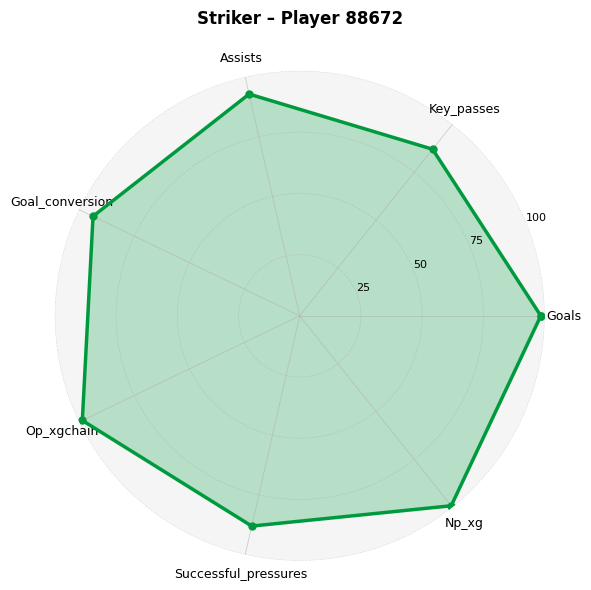


Percentile values for Striker – Player 88672:
  Goals: 0.98
  Key_passes: 0.87
  Assists: 0.93
  Goal_conversion: 0.94
  Op_xgchain: 0.99
  Successful_pressures: 0.88
  Np_xg: 0.99


In [ ]:
# radar diagram
player_id_striker = 88672

striker_metrics = [
    "Goals",
    "Key_passes",
    "Assists",
    "Goal_conversion",
    "Op_xgchain",
    "Successful_pressures",
    "Np_xg",
]

radar_chart_for_player(
    filtered_scored_df,
    player_id_striker,
    striker_metrics,
    id_col="ID",
    title="Striker – Player 88672"
)


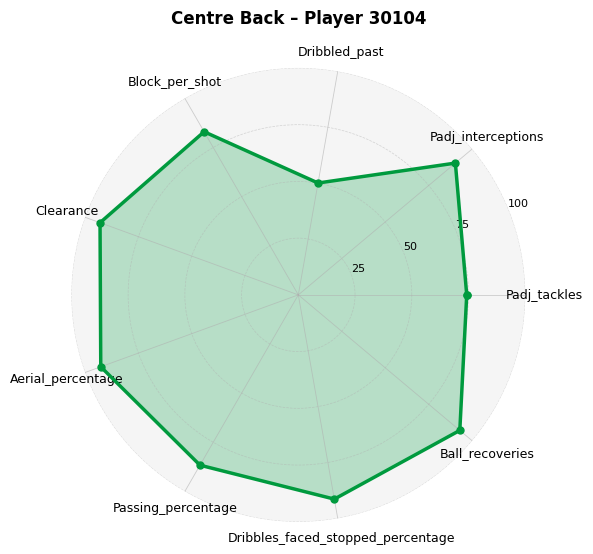


Percentile values for Centre Back – Player 30104:
  Padj_tackles: 0.74
  Padj_interceptions: 0.90
  Dribbled_past: 0.50
  Block_per_shot: 0.83
  Clearance: 0.93
  Aerial_percentage: 0.93
  Passing_percentage: 0.87
  Dribbles_faced_stopped_percentage: 0.91
  Ball_recoveries: 0.93


In [ ]:
player_id_centre_back = 30104

centre_back_metrics = [
    "Padj_tackles",
    "Padj_interceptions",
    "Dribbled_past",
    "Block_per_shot",
    "Clearance",
    "Aerial_percentage",
    "Passing_percentage",
    "Dribbles_faced_stopped_percentage",
    "Ball_recoveries",
]

radar_chart_for_player(
    filtered_scored_df,
    player_id_centre_back,
    centre_back_metrics,
    id_col="ID",
    title="Centre Back – Player 30104"
)


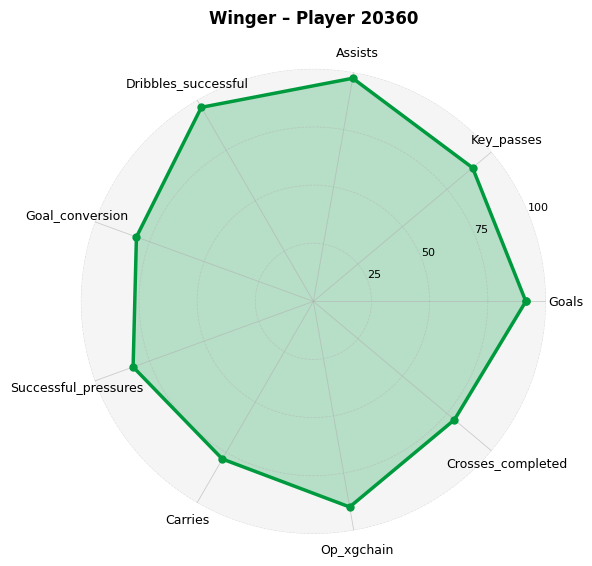


Percentile values for Winger – Player 20360:
  Goals: 0.91
  Key_passes: 0.89
  Assists: 0.97
  Dribbles_successful: 0.96
  Goal_conversion: 0.81
  Successful_pressures: 0.83
  Carries: 0.78
  Op_xgchain: 0.90
  Crosses_completed: 0.79


In [ ]:
player_id_winger = 20360

winger_metrics = [
    "Goals", "Key_passes", "Assists", "Dribbles_successful", "Goal_conversion", "Successful_pressures", "Carries", "Op_xgchain", "Crosses_completed",
]

radar_chart_for_player(
    filtered_scored_df,
    player_id_winger,
    winger_metrics,
    id_col="ID",
    title="Winger – Player 20360"
)


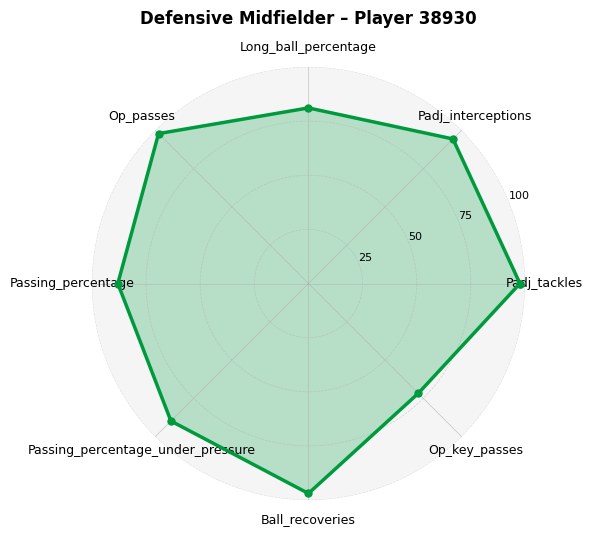


Percentile values for Defensive Midfielder – Player 38930:
  Padj_tackles: 0.98
  Padj_interceptions: 0.94
  Long_ball_percentage: 0.81
  Op_passes: 0.98
  Passing_percentage: 0.88
  Passing_percentage_under_pressure: 0.90
  Ball_recoveries: 0.97
  Op_key_passes: 0.72


In [ ]:
player_id_def_mid = 38930

def_mid_metrics = [
    "Padj_tackles", "Padj_interceptions", "Long_ball_percentage", "Op_passes", "Passing_percentage", "Passing_percentage_under_pressure", "Ball_recoveries", "Op_key_passes",
]

radar_chart_for_player(
    filtered_scored_df,
    player_id_def_mid ,
    def_mid_metrics,
    id_col="ID",
    title="Defensive Midfielder – Player 38930"
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def radar_chart_multi(
    df,
    player_ids,
    metrics,
    id_col="ID",
    labels=None,
    title=None,
    main_color="#009A3E",  # Celtic green for chosen valuable player
    other_colors=None
):
    """
    Radar chart comparing multiple players, styled to match the single-player radar.

    player_ids: list of IDs (first one will be highlighted in main_color)
    metrics: list of base metric names (without _pct)
    labels: list of names for legend (optional, defaults to str(ID))
    main_color: colour for the first player (default Celtic green)
    other_colors: list of colours for the remaining players (optional)
    """
    if labels is None:
        labels = [str(pid) for pid in player_ids]

    n_metrics = len(metrics)
    if n_metrics == 0:
        raise ValueError("No metrics provided for radar_chart_multi.")

    # Prepare angles for axes
    angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False)
    angles = np.concatenate([angles, angles[:1]])

    # Default colours for comparison players
    if other_colors is None:
        other_colors = ["#4c4c4c", "#1f77b4", "#ff7f0e", "#8c564b"]  # neutral palette

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, polar=True)

    # ---- Background & grid styling  ----
    ax.set_facecolor("#f5f5f5")
    ax.grid(True, linewidth=0.6, alpha=0.6)
    ax.spines["polar"].set_visible(False)

    # ---- Plot each player ----
    for idx, (pid, lab) in enumerate(zip(player_ids, labels)):
        row = df[df[id_col] == pid]
        if row.empty:
            print(f"Warning: no player with {id_col} = {pid}")
            continue
        row = row.iloc[0]

        vals = []
        for m in metrics:
            col = f"{m}_pct"
            if col not in df.columns:
                vals.append(np.nan)
                continue
            v = row[col]
            vals.append(float(v) if not pd.isna(v) else np.nan)

        vals = np.array(vals, dtype=float)

        # Skip players with no valid metrics
        if np.all(np.isnan(vals)):
            print(f"Warning: no valid metrics for player {pid}")
            continue

        # Replace NaNs with 0 for plotting
        vals = np.nan_to_num(vals, nan=0.0)

        vals = np.concatenate([vals, vals[:1]])

        # Style: first player highlighted in Celtic green, others neutral
        if idx == 0:
            color = main_color
            lw = 2.5
            alpha_fill = 0.25
            linestyle = "-"
            marker = "o"
            ms = 5
        else:
            color = other_colors[(idx - 1) % len(other_colors)]
            lw = 1.5
            alpha_fill = 0.15
            linestyle = "--"
            marker = "o"
            ms = 4

        ax.plot(
            angles,
            vals,
            label=lab,
            color=color,
            linewidth=lw,
            linestyle=linestyle,
            marker=marker,
            markersize=ms,
        )
        ax.fill(
            angles,
            vals,
            color=color,
            alpha=alpha_fill
        )

    # ---- Axis / label styling ----
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=9)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("center")

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25", "50", "75", "100"], fontsize=8)
    ax.tick_params(axis="y", labelsize=8)

    # Light dashed radial grid lines
    for line in ax.yaxis.get_gridlines():
        line.set_linestyle("--")
        line.set_linewidth(0.5)
        line.set_alpha(0.5)

    # ---- Title & legend ----
    if title is None:
        title = "Player comparison"

    ax.set_title(
        title,
        y=1.08,
        fontsize=12,
        fontweight="bold"
    )

    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

    plt.tight_layout()
    plt.show()


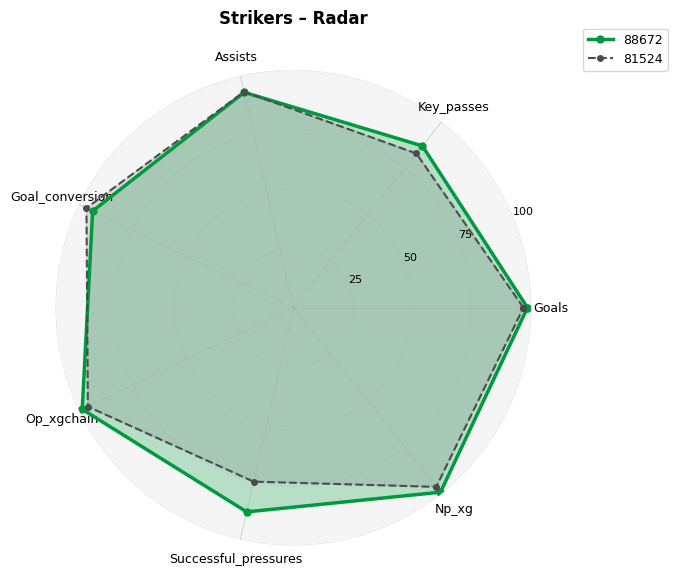

In [ ]:
striker_metrics = [
    "Goals",
    "Key_passes",
    "Assists",
    "Goal_conversion",
    "Op_xgchain",
    "Successful_pressures",
    "Np_xg",
]

striker_ids = [88672, 81524]
striker_labels = ["88672", "81524"]

radar_chart_multi(filtered_scored_df, striker_ids, striker_metrics, id_col="ID",
                  labels=striker_labels, title="Strikers – Radar")


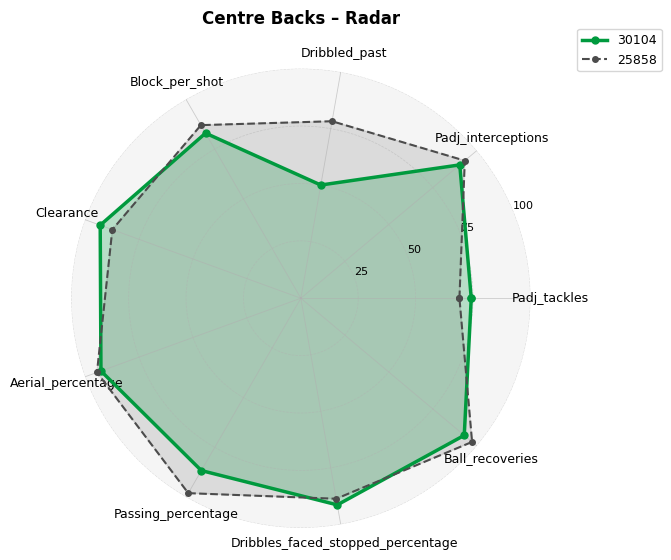

In [ ]:
centre_back_metrics = [
    "Padj_tackles",
    "Padj_interceptions",
    "Dribbled_past",
    "Block_per_shot",
    "Clearance",
    "Aerial_percentage",
    "Passing_percentage",
    "Dribbles_faced_stopped_percentage",
    "Ball_recoveries",
]

centre_back_ids = [30104, 25858]
centre_back_labels = ["30104", "25858"]

radar_chart_multi(filtered_scored_df, centre_back_ids, centre_back_metrics, id_col="ID",
                  labels=centre_back_labels, title="Centre Backs – Radar")


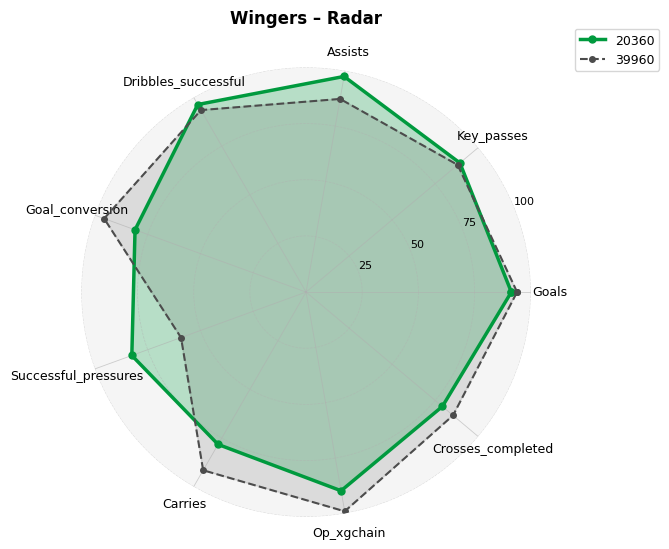

In [ ]:
winger_ids = [20360, 39960]
winger_labels = ["20360", "39960"]

radar_chart_multi(filtered_scored_df, winger_ids, winger_metrics, id_col="ID",
                  labels=winger_labels, title="Wingers – Radar")


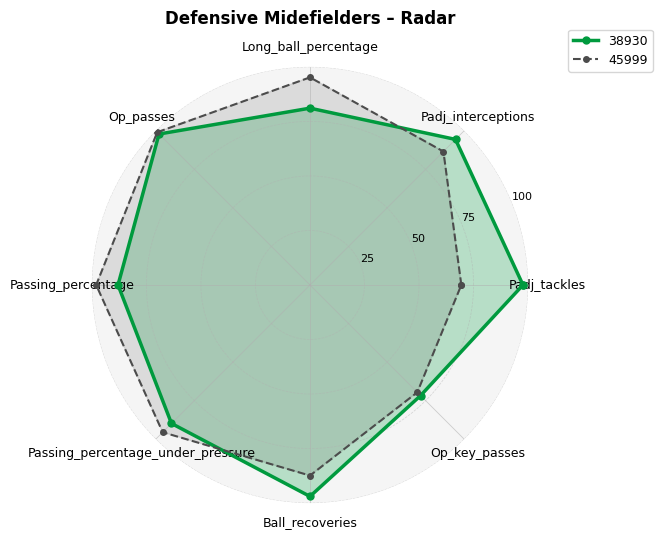

In [ ]:
def_mid_ids = [38930, 45999]
def_mid_labels = ["38930", "45999"]

radar_chart_multi(filtered_scored_df, def_mid_ids, def_mid_metrics, id_col="ID",
                  labels=def_mid_labels, title="Defensive Midefielders – Radar")


In [ ]:
import pandas as pd
from IPython.display import display

# ===== CONFIG – change these if your column names differ =====
ID_COL = "ID"
AGE_COL = "Age"
MINUTES_COL = "Minutes"
POS1_COL = "Position_1"
POS2_COL = "Position_2"
VALUE_COL = "Value"      # change if it's 'Market_Value', etc.
NAME_COL = "Player"      # change if it's 'Name', 'Player_Name', etc.
CLUB_COL = "Team"        # column that has 'Celtic' in it

POSITION_GROUP_COL = "Position_Group"

# The order of position groups you’ve been using
group_order = [
    "Goalkeeper",
    "Fullback",
    "Centre Back",
    "Defensive Midfielder",
    "Central Midfielder",
    "Attacking Midfielder",
    "Wide Midfielder",
    "Winger",
    "Striker",
]

# ===== 1. Filter to Celtic players (in the minutes-filtered, scored dataset) =====
# Use filtered_scored_df so you're only looking at players above your minutes threshold.
celtic_df = filtered_scored_df[filtered_scored_df[CLUB_COL] == "Celtic"].copy()

print("Total Celtic rows (player-position combinations):", len(celtic_df))

# Columns to show in the tables
cols_to_show = [
    col for col in [
        ID_COL,
        NAME_COL,
        AGE_COL,
        MINUTES_COL,
        VALUE_COL,
        POS1_COL,
        POS2_COL,
        POSITION_GROUP_COL,
        "Positional_Score",
    ]
    if col in celtic_df.columns
]

# ===== 2. Display Celtic players by position group =====
for g in group_order:
    gdf = celtic_df[celtic_df[POSITION_GROUP_COL] == g].copy()
    if gdf.empty:
        continue

    # Sort by Positional_Score desc, then Minutes desc (if available)
    sort_cols = []
    ascending = []
    if "Positional_Score" in gdf.columns:
        sort_cols.append("Positional_Score")
        ascending.append(False)
    if MINUTES_COL in gdf.columns:
        sort_cols.append(MINUTES_COL)
        ascending.append(False)

    if sort_cols:
        gdf = gdf.sort_values(sort_cols, ascending=ascending)

    print(f"\n=== Celtic – {g} ===")
    display(gdf[cols_to_show])


Total Celtic rows (player-position combinations): 26

=== Celtic – Goalkeeper ===


,ID,Age,Minutes,Value,Position_1,Position_2,Position_Group,Positional_Score
4629,73869,39,3143.017,500.0k,Goalkeeper,NaN,Goalkeeper,0.563905



=== Celtic – Fullback ===


,ID,Age,Minutes,Value,Position_1,Position_2,Position_Group,Positional_Score
4532,79374,27,901.550,1.5m,Right Back,NaN,Fullback,0.724204
4529,81887,28,2189.633,6.0m,Left Back,Left Centre Midfielder,Fullback,0.697697
4590,49759,27,2852.450,10.0m,Right Back,NaN,Fullback,0.693575
4303,78232,27,2200.250,4.0m,Left Centre Back,Left Back,Fullback,0.658999



=== Celtic – Centre Back ===


...

,ID,Age,Minutes,Value,Position_1,Position_2,Position_Group,Positional_Score
4621,77021,25,2027.767,12.0m,Right Wingerer,Right Midfielder,Wide Midfielder,0.750091



=== Celtic – Winger ===


,ID,Age,Minutes,Value,Position_1,Position_2,Position_Group,Positional_Score
4309,39960,23,1089.050,2.5m,Right Wingerer,Left Winger,Winger,0.793475
4621,77021,25,2027.767,12.0m,Right Wingerer,Right Midfielder,Winger,0.782381
4617,81524,28,2744.967,15.0m,Left Wing,Centre Forward,Winger,0.752358
4530,69648,34,1027.250,500.0k,Right Wingerer,Left Winger,Winger,0.705713
4618,38067,30,1431.000,9.0m,Centre Forward,Right Winger,Winger,0.632521



=== Celtic – Striker ===


,ID,Age,Minutes,Value,Position_1,Position_2,Position_Group,Positional_Score
4617,81524,28,2744.967,15.0m,Left Wing,Centre Forward,Striker,0.805035
4292,27790,24,1866.200,6.5m,Centre Forward,NaN,Striker,0.734252
4618,38067,30,1431.000,9.0m,Centre Forward,Right Winger,Striker,0.708499
